In [581]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_score, f1_score, recall_score


In [582]:
df = pd.read_csv("/content/Investment_Worthy_Raw_Dataset_.csv")

In [583]:
df.head()

,Company_Name,Industry,Company_Age_Years,Annual_Revenue,Revenue_Growth_Pct,Profit_Margin_Pct,Debt_to_Equity,Current_Ratio,ROE_Pct,Market_Share_Pct,Customer_Growth_Pct,Customer_Retention_Pct,Management_Experience_Years,Business_Risk,Market_Risk,Expected_ROI_Pct,Investment_Amount,Industry_Growth_Pct,Investment_Decision
0,Company_00001,Retail,24,28985366.0,11.96,12.14,0.46,1.44,17.97,6.70,8.68,63.54,17.2,Low,High,21.82,6315297.0,5.74,Yes
1,Company_00002,Real Estate,5,56481436.0,12.60,12.60,0.66,1.76,17.32,12.65,20.70,81.57,3.4,Low,Medium,9.13,10430140.0,8.31,Yes
2,Company_00003,FMCG,19,12789507.0,1.09,15.26,0.83,1.19,17.67,10.43,-2.93,84.27,14.1,Low,Medium,14.26,962881.0,9.95,Yes
3,Company_00004,Energy,6,24852957.0,10.92,7.71,1.32,2.11,4.96,9.23,10.83,86.92,11.5,Medium,Low,17.14,2020293.0,10.76,Yes
4,Company_00005,Healthcare,17,81096738.0,23.20,7.28,0.63,1.66,19.03,6.62,33.52,82.47,8.1,Medium,Low,13.59,15001589.0,17.69,Yes


In [584]:
df.isnull().sum()

,0
Company_Name,0
Industry,0
Company_Age_Years,0
Annual_Revenue,0
Revenue_Growth_Pct,200
Profit_Margin_Pct,200
Debt_to_Equity,0
Current_Ratio,200
ROE_Pct,0
Market_Share_Pct,200


In [585]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Company_Name                 10000 non-null  object 
 1   Industry                     10000 non-null  object 
 2   Company_Age_Years            10000 non-null  int64  
 3   Annual_Revenue               10000 non-null  float64
 4   Revenue_Growth_Pct           9800 non-null   float64
 5   Profit_Margin_Pct            9800 non-null   float64
 6   Debt_to_Equity               10000 non-null  float64
 7   Current_Ratio                9800 non-null   float64
 8   ROE_Pct                      10000 non-null  float64
 9   Market_Share_Pct             9800 non-null   float64
 10  Customer_Growth_Pct          10000 non-null  float64
 11  Customer_Retention_Pct       9800 non-null   float64
 12  Management_Experience_Years  10000 non-null  float64
 13  Business_Risk    

In [586]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns
#

In [587]:
print("Numeric Columns:")
print(numeric_columns)
print("\nCategorical Columns:")
print(categorical_columns)

Numeric Columns:
Index(['Company_Age_Years', 'Annual_Revenue', 'Revenue_Growth_Pct',
       'Profit_Margin_Pct', 'Debt_to_Equity', 'Current_Ratio', 'ROE_Pct',
       'Market_Share_Pct', 'Customer_Growth_Pct', 'Customer_Retention_Pct',
       'Management_Experience_Years', 'Expected_ROI_Pct', 'Investment_Amount',
       'Industry_Growth_Pct'],
      dtype='object')

Categorical Columns:
Index(['Company_Name', 'Industry', 'Business_Risk', 'Market_Risk',
       'Investment_Decision'],
      dtype='object')


In [588]:
df["Revenue_Growth_Pct"] = df["Revenue_Growth_Pct"].fillna(df["Revenue_Growth_Pct"].median())
df["Profit_Margin_Pct"] = df["Profit_Margin_Pct"].fillna(df["Profit_Margin_Pct"].median())
df["Current_Ratio"] = df["Current_Ratio"].fillna(df["Current_Ratio"].median())
df["Market_Share_Pct"] = df["Market_Share_Pct"].fillna(df["Market_Share_Pct"].median())
df["Customer_Retention_Pct"] = df["Customer_Retention_Pct"].fillna(df["Customer_Retention_Pct"].median())

In [589]:
df.shape

(10000, 19)

In [590]:
df.describe()

,Company_Age_Years,Annual_Revenue,Revenue_Growth_Pct,Profit_Margin_Pct,Debt_to_Equity,Current_Ratio,ROE_Pct,Market_Share_Pct,Customer_Growth_Pct,Customer_Retention_Pct,Management_Experience_Years,Expected_ROI_Pct,Investment_Amount,Industry_Growth_Pct
count,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000
mean,15.968100,7.061546e+07,13.391299,9.945896,0.878774,1.737652,14.478467,6.163153,15.349605,80.479775,13.179030,14.826702,1.212321e+07,10.388331
std,8.266481,7.101981e+07,8.084511,5.244106,0.523988,0.538249,8.645906,4.373882,10.080471,7.944960,4.770585,6.606538,1.314543e+07,4.111362
min,2.000000,2.237143e+06,-12.000000,-8.000000,0.080000,0.450000,-15.000000,0.540000,-15.000000,48.100000,2.000000,-5.000000,5.000000e+05,-3.000000
25%,9.000000,2.758076e+07,8.030000,6.490000,0.520000,1.380000,8.630000,3.300000,8.470000,75.090000,9.800000,10.387500,4.081658e+06,7.440000
50%,16.000000,4.965114e+07,13.360000,9.920000,0.760000,1.740000,14.470000,5.010000,15.270000,80.535000,13.200000,14.730000,7.905364e+06,10.060000
75%,23.000000,8.826520e+07,18.730000,13.420000,1.100000,2.100000,20.212500,7.610000,21.982500,85.850000,16.700000,19.272500,1.500172e+07,13.090000
max,30.000000,1.152748e+09,40.000000,29.280000,4.500000,3.770000,45.000000,35.000000,45.000000,99.000000,25.000000,39.470000,1.000000e+08,26.830000


In [591]:
df.isnull().sum()
#

,0
Company_Name,0
Industry,0
Company_Age_Years,0
Annual_Revenue,0
Revenue_Growth_Pct,0
Profit_Margin_Pct,0
Debt_to_Equity,0
Current_Ratio,0
ROE_Pct,0
Market_Share_Pct,0


In [592]:
df.nunique()

,0
Company_Name,10000
Industry,10
Company_Age_Years,29
Annual_Revenue,9999
Revenue_Growth_Pct,3205
Profit_Margin_Pct,2335
Debt_to_Equity,330
Current_Ratio,301
ROE_Pct,3399
Market_Share_Pct,1668


In [593]:
df['Investment_Decision'].value_counts()

,count
Investment_Decision,
Yes,6456
No,3544


In [594]:
df.duplicated().sum()

np.int64(0)

In [595]:
df['Company_Name'].duplicated().sum()

np.int64(0)

In [596]:
df.dtypes

,0
Company_Name,object
Industry,object
Company_Age_Years,int64
Annual_Revenue,float64
Revenue_Growth_Pct,float64
Profit_Margin_Pct,float64
Debt_to_Equity,float64
Current_Ratio,float64
ROE_Pct,float64
Market_Share_Pct,float64


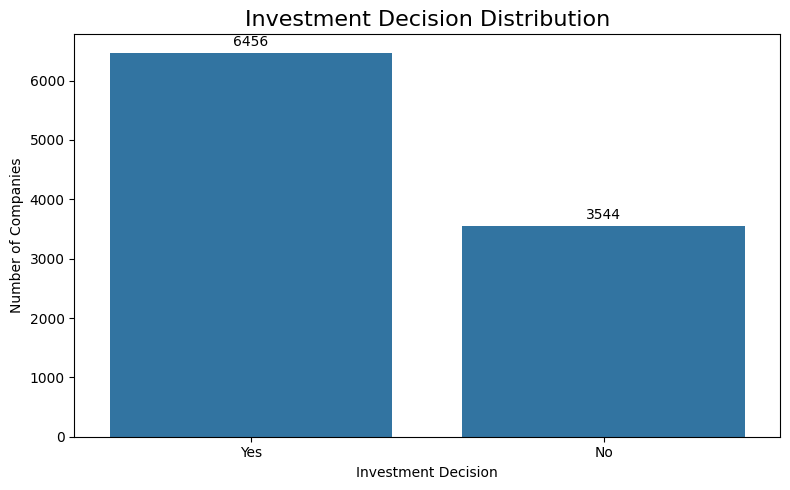

In [597]:

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Investment_Decision'
)

plt.title('Investment Decision Distribution', fontsize=16)
plt.xlabel('Investment Decision')
plt.ylabel('Number of Companies')

# Data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

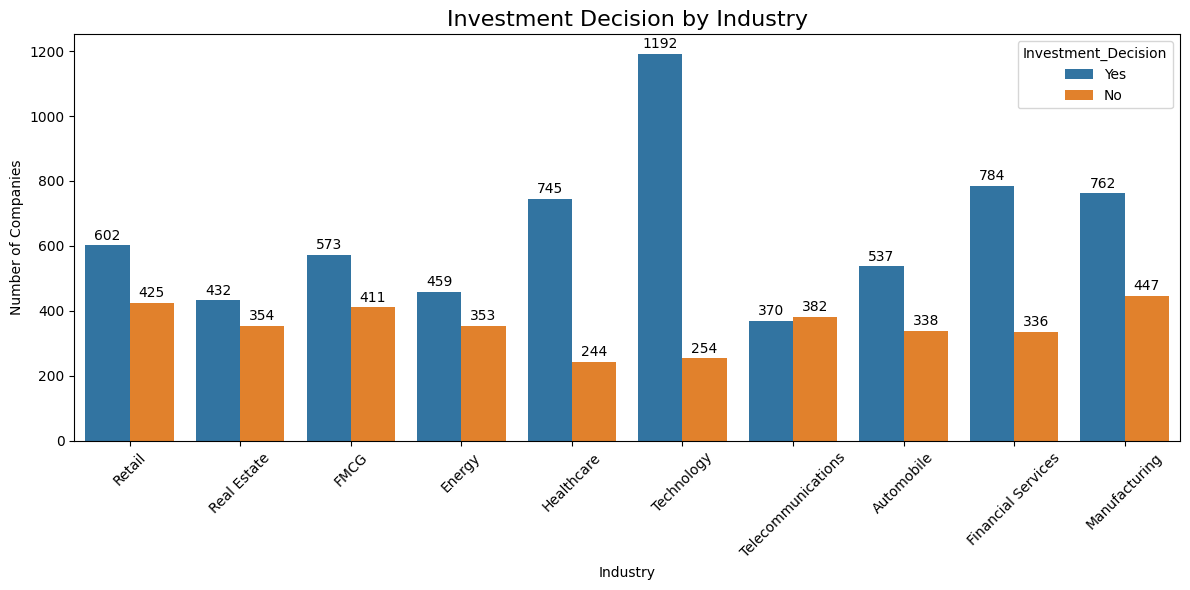

In [598]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df,
    x='Industry',
    hue='Investment_Decision'
)

plt.title('Investment Decision by Industry', fontsize=16)
plt.xlabel('Industry')
plt.ylabel('Number of Companies')
plt.xticks(rotation=45)

# Data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2)

plt.tight_layout()
plt.show()

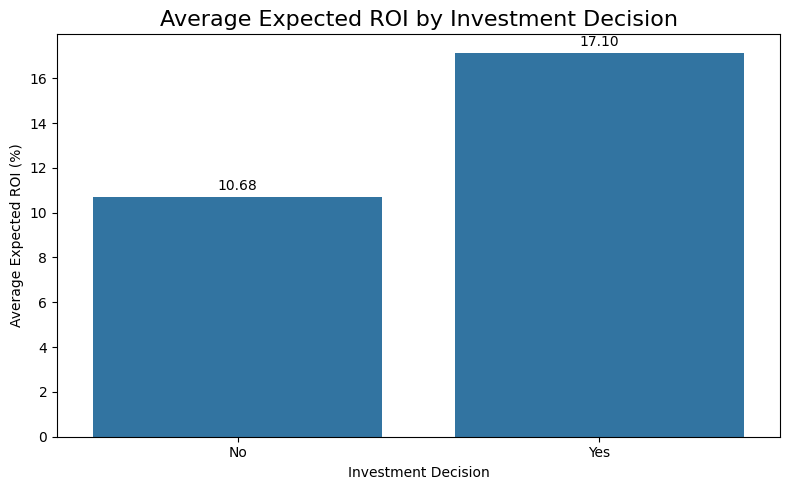

In [599]:
roi_avg = df.groupby('Investment_Decision')['Expected_ROI_Pct'].mean().reset_index()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=roi_avg,
    x='Investment_Decision',
    y='Expected_ROI_Pct'
)

plt.title('Average Expected ROI by Investment Decision', fontsize=16)
plt.xlabel('Investment Decision')
plt.ylabel('Average Expected ROI (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

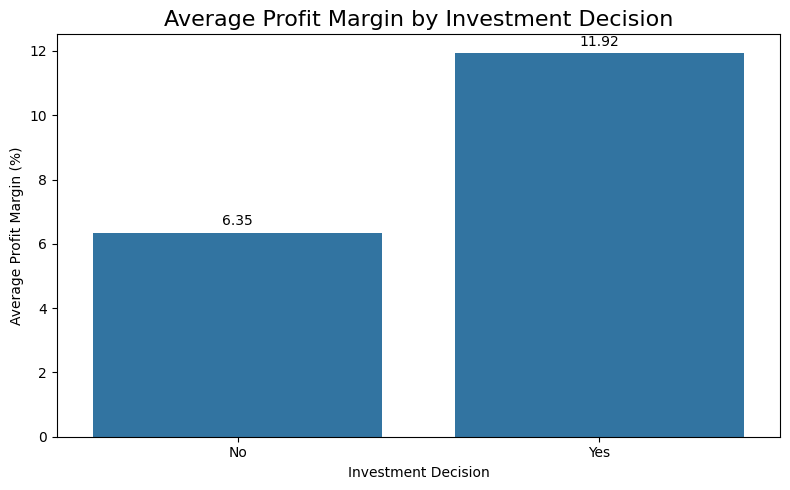

In [600]:
profit_avg = df.groupby('Investment_Decision')['Profit_Margin_Pct'].mean().reset_index()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=profit_avg,
    x='Investment_Decision',
    y='Profit_Margin_Pct'
)

plt.title('Average Profit Margin by Investment Decision', fontsize=16)
plt.xlabel('Investment Decision')
plt.ylabel('Average Profit Margin (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

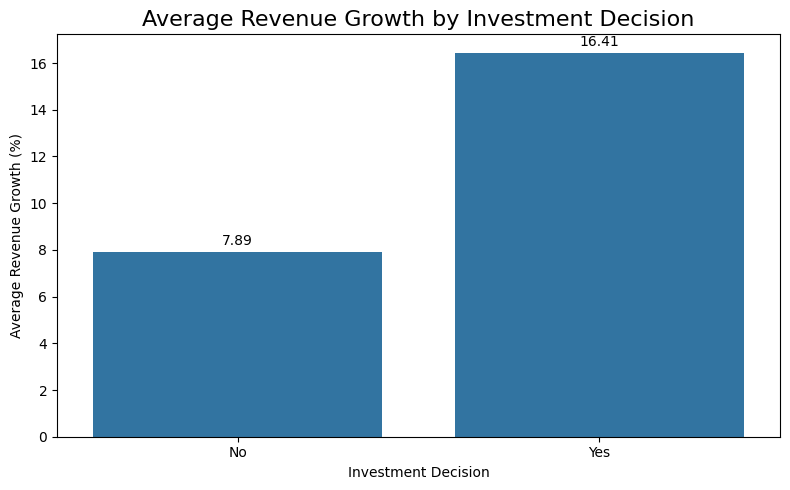

In [601]:
plt.figure(figsize=(8,5))

revenue_growth_avg = (
    df.groupby('Investment_Decision')['Revenue_Growth_Pct']
    .mean()
    .reset_index()
)

ax = sns.barplot(
    data=revenue_growth_avg,
    x='Investment_Decision',
    y='Revenue_Growth_Pct'
)

plt.title('Average Revenue Growth by Investment Decision', fontsize=16)
plt.xlabel('Investment Decision')
plt.ylabel('Average Revenue Growth (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

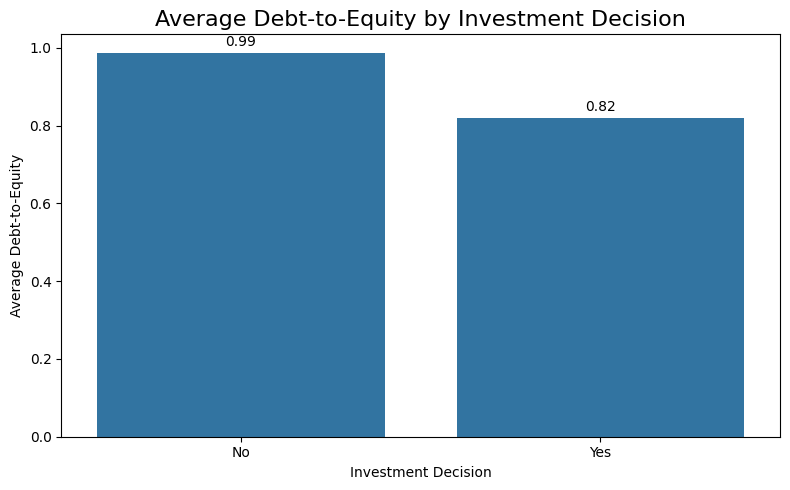

In [602]:
plt.figure(figsize=(8,5))

de_avg = (
    df.groupby('Investment_Decision')['Debt_to_Equity']
    .mean()
    .reset_index()
)

ax = sns.barplot(
    data=de_avg,
    x='Investment_Decision',
    y='Debt_to_Equity'
)

plt.title('Average Debt-to-Equity by Investment Decision', fontsize=16)
plt.xlabel('Investment Decision')
plt.ylabel('Average Debt-to-Equity')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

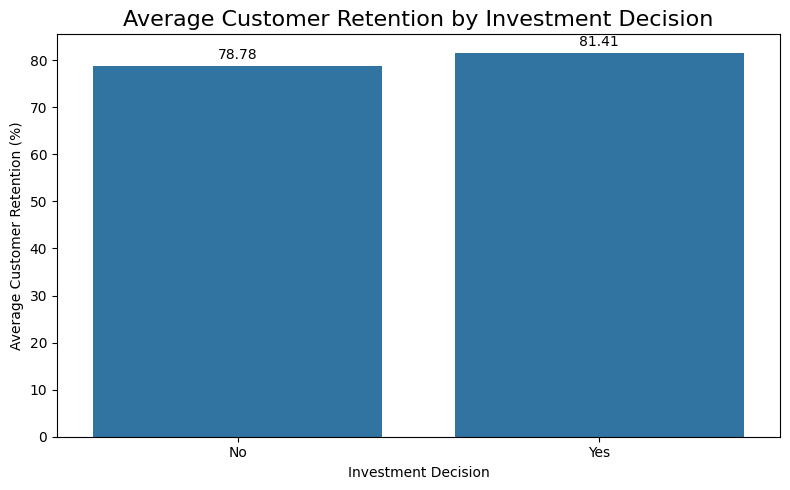

In [603]:
plt.figure(figsize=(8,5))

retention_avg = (
    df.groupby('Investment_Decision')['Customer_Retention_Pct']
    .mean()
    .reset_index()
)

ax = sns.barplot(
    data=retention_avg,
    x='Investment_Decision',
    y='Customer_Retention_Pct'
)

plt.title('Average Customer Retention by Investment Decision', fontsize=16)
plt.xlabel('Investment Decision')
plt.ylabel('Average Customer Retention (%)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

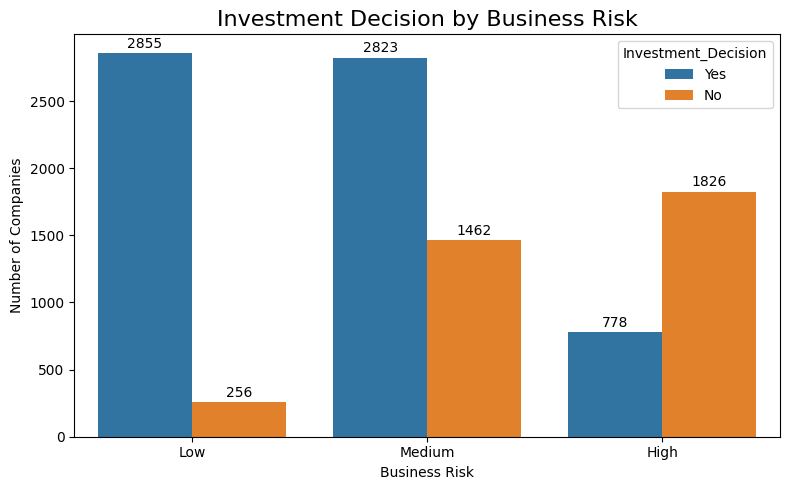

In [604]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Business_Risk',
    hue='Investment_Decision'
)

plt.title('Investment Decision by Business Risk', fontsize=16)
plt.xlabel('Business Risk')
plt.ylabel('Number of Companies')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2)

plt.tight_layout()
plt.show()

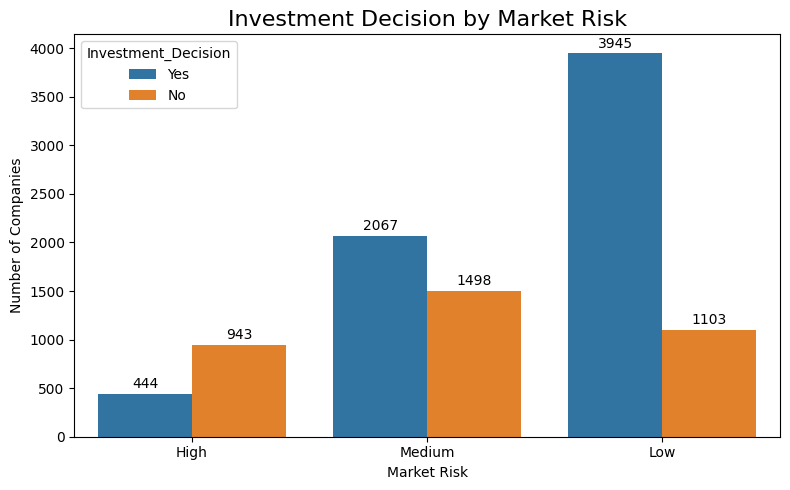

In [605]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Market_Risk',
    hue='Investment_Decision'
)

plt.title('Investment Decision by Market Risk', fontsize=16)
plt.xlabel('Market Risk')
plt.ylabel('Number of Companies')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2)

plt.tight_layout()
plt.show()

In [606]:
# Encoding Categorical Variables


encoders = {}

for column in df.columns:
    if df[column].dtype == "object":
        le = LabelEncoder()
        df[column] = le.fit_transform(df[column])
        encoders[column] = le

# Display first five rows

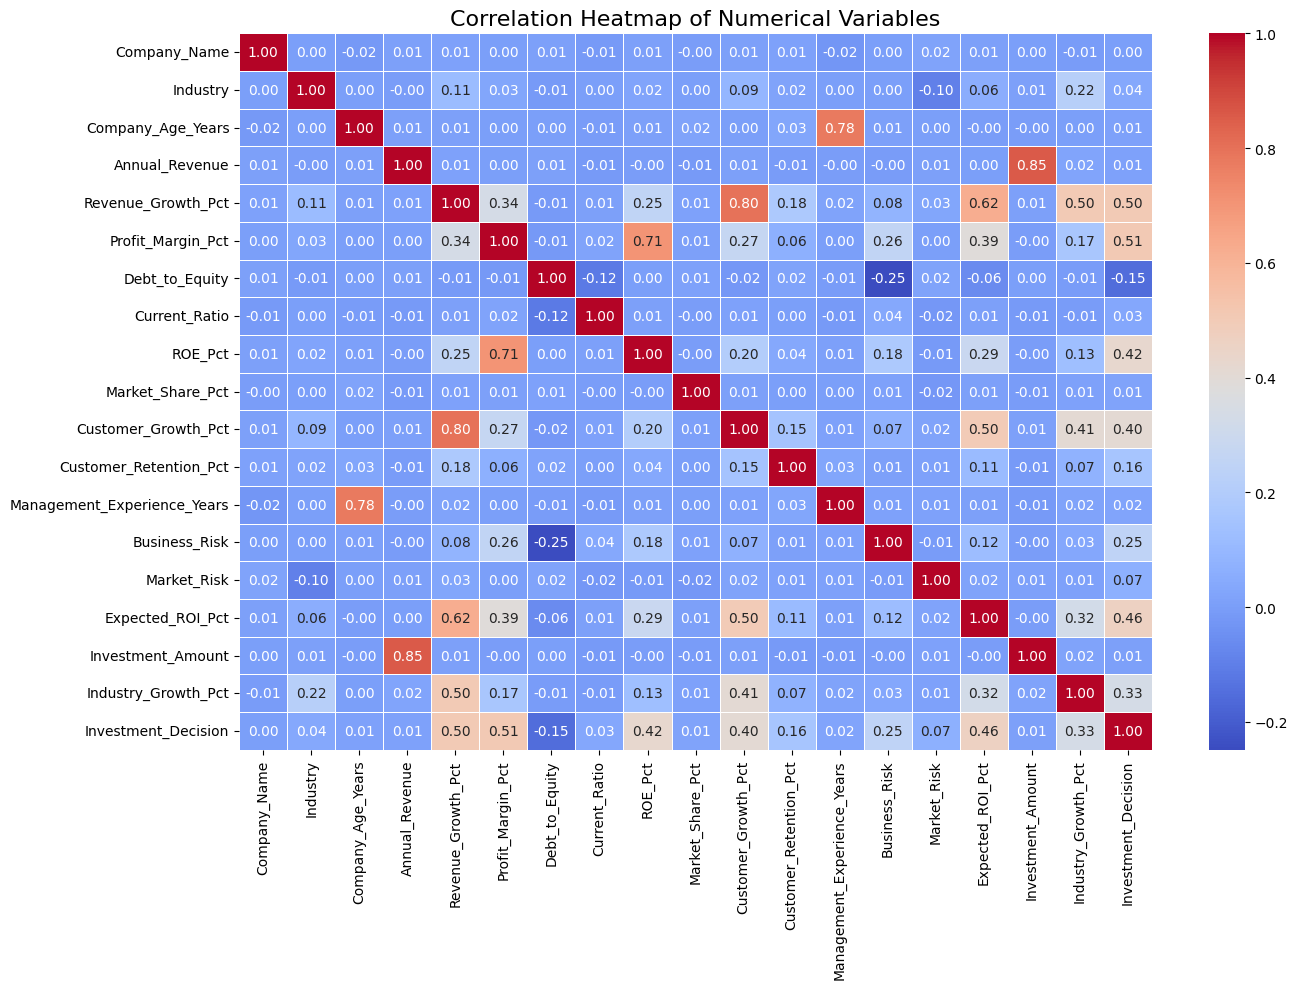

In [607]:
plt.figure(figsize=(14, 10))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()

In [608]:
df.columns

Index(['Company_Name', 'Industry', 'Company_Age_Years', 'Annual_Revenue',
       'Revenue_Growth_Pct', 'Profit_Margin_Pct', 'Debt_to_Equity',
       'Current_Ratio', 'ROE_Pct', 'Market_Share_Pct', 'Customer_Growth_Pct',
       'Customer_Retention_Pct', 'Management_Experience_Years',
       'Business_Risk', 'Market_Risk', 'Expected_ROI_Pct', 'Investment_Amount',
       'Industry_Growth_Pct', 'Investment_Decision'],
      dtype='object')

In [609]:
X = df[[ 'Industry',
       'Revenue_Growth_Pct', 'Profit_Margin_Pct', 'Debt_to_Equity',
        'ROE_Pct', 'Customer_Growth_Pct',
       'Customer_Retention_Pct',
       'Business_Risk', 'Expected_ROI_Pct', 'Investment_Amount',
       'Industry_Growth_Pct']]
y = df['Investment_Decision']

In [610]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [611]:
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [612]:
y_pred = model.predict(X_test)

In [613]:
class_report = classification_report(y_test, y_pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.76      0.64      0.70       714
           1       0.82      0.89      0.85      1286

    accuracy                           0.80      2000
   macro avg       0.79      0.76      0.77      2000
weighted avg       0.80      0.80      0.80      2000



In [614]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 456  258]
 [ 141 1145]]


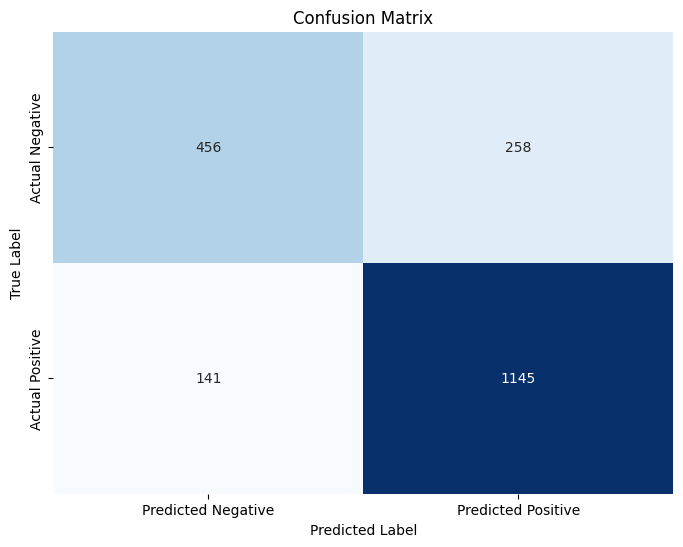

In [615]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [616]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

In [647]:
grid_search = GridSearchCV(
    LogisticRegression(
        C =0.00001,
        random_state=42,
        max_iter=1000
    ),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [618]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(C=1e-05, max_iter=1000,
                                          random_state=42),
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='accuracy')

In [619]:
print(grid_search.best_params_)

{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}


In [620]:
y_pred_after = grid_search.predict(X_test)

In [621]:
accuracy_after = accuracy_score(y_test, y_pred_after)
precision_after = precision_score(y_test, y_pred_after)
f1_after = f1_score(y_test, y_pred_after)
recall_after = recall_score(y_test, y_pred_after)

In [622]:
print(f"Accuracy: {accuracy_after:.2f}")
print(f"Precision: {precision_after:.2f}")

Accuracy: 0.85
Precision: 0.86


In [623]:
class_report_after = classification_report(y_test, y_pred_after)
print(class_report_after)

              precision    recall  f1-score   support

           0       0.81      0.75      0.78       714
           1       0.86      0.90      0.88      1286

    accuracy                           0.85      2000
   macro avg       0.84      0.82      0.83      2000
weighted avg       0.84      0.85      0.84      2000



In [624]:
cm_after = confusion_matrix(y_test, y_pred_after)
print(cm_after)

[[ 532  182]
 [ 126 1160]]


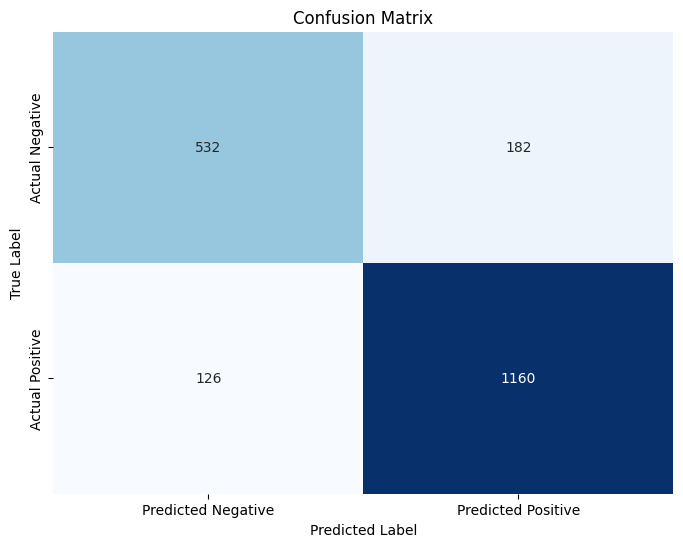

In [625]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_after, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [626]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],

    'Before Tuning': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],

    'After Tuning': [
        accuracy_score(y_test, y_pred_after),
        precision_score(y_test, y_pred_after),
        recall_score(y_test, y_pred_after),
        f1_score(y_test, y_pred_after)
    ]
})

results = results.round(4)

print(results)

      Metric  Before Tuning  After Tuning
0   Accuracy         0.8005        0.8460
1  Precision         0.8161        0.8644
2     Recall         0.8904        0.9020
3   F1 Score         0.8516        0.8828


In [627]:
industry = input(
    "Enter Industry: "
)

revenue_growth = float(input("Enter Revenue Growth (%): "))
profit_margin = float(input("Enter Profit Margin (%): "))
debt_to_equity = float(input("Enter Debt to Equity: "))
roe = float(input("Enter ROE (%): "))
customer_growth = float(input("Enter Customer Growth (%): "))
customer_retention = float(input("Enter Customer Retention (%): "))

business_risk = input(
    "Enter Business Risk (Low/Medium/High): "
)

expected_roi = float(input("Enter Expected ROI (%): "))
investment_amount = float(input("Enter Investment Amount: "))
industry_growth = float(input("Enter Industry Growth (%): "))

Enter Industry: FMCG
Enter Revenue Growth (%): 1.09
Enter Profit Margin (%): 15.26
Enter Debt to Equity: 0.83
Enter ROE (%): 17.67
Enter Customer Growth (%): -2.93
Enter Customer Retention (%): 84.27
Enter Business Risk (Low/Medium/High): Low
Enter Expected ROI (%): 14.26
Enter Investment Amount: 962881
Enter Industry Growth (%): 9.95


In [628]:
user_data = pd.DataFrame({
    'Industry': [industry],
    'Revenue_Growth_Pct': [revenue_growth],
    'Profit_Margin_Pct': [profit_margin],
    'Debt_to_Equity': [debt_to_equity],
    'ROE_Pct': [roe],
    'Customer_Growth_Pct': [customer_growth],
    'Customer_Retention_Pct': [customer_retention],
    'Business_Risk': [business_risk],
    'Expected_ROI_Pct': [expected_roi],
    'Investment_Amount': [investment_amount],
    'Industry_Growth_Pct': [industry_growth]
})

In [629]:
user_data['Industry'] = encoders['Industry'].transform(
    user_data['Industry'].str.strip()
)

user_data['Business_Risk'] = encoders['Business_Risk'].transform(
    user_data['Business_Risk'].str.strip()
)

In [630]:
user_data = user_data[X.columns]

In [631]:

prediction =  model.predict(user_data)[0]

probability =  model.predict_proba(user_data)[0][1]

In [632]:
print("\n" + "="*50)

if prediction == 1:
    print("✅ INVESTMENT WORTHY")
else:
    print("❌ NOT INVESTMENT WORTHY")

print(f"Investment Worthiness Probability: {probability * 100:.2f}%")

print("="*50)


✅ INVESTMENT WORTHY
Investment Worthiness Probability: 52.66%


In [633]:

prediction =   grid_search.predict(user_data)[0]

probability =  grid_search.predict_proba(user_data)[0][1]

In [634]:
print("\n" + "="*50)

if prediction == 1:
    print("✅ INVESTMENT WORTHY")
else:
    print("❌ NOT INVESTMENT WORTHY")

print(f"Investment Worthiness Probability: {probability * 100:.2f}%")

print("="*50)


✅ INVESTMENT WORTHY
Investment Worthiness Probability: 73.38%


In [635]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
decision_tree = DecisionTreeClassifier(
    random_state=42
)

# Train the model
decision_tree.fit(X_train, y_train)

# Prediction
y_pred_dt = decision_tree.predict(X_test)

# Probability
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

In [636]:

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy :", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall   :", round(recall_dt, 4))
print("F1 Score :", round(f1_dt, 4))

Decision Tree Performance
-------------------------
Accuracy : 0.813
Precision: 0.8636
Recall   : 0.8421
F1 Score : 0.8528


In [637]:
confusion_matrix_dt = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix:")
print(confusion_matrix_dt)

Confusion Matrix:
[[ 543  171]
 [ 203 1083]]


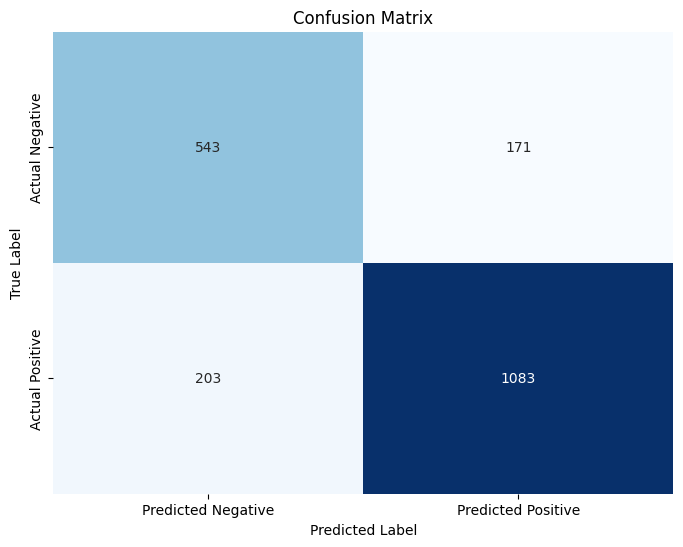

In [638]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [639]:
class_report_dt = classification_report(y_test, y_pred_dt)
print(class_report_dt)

              precision    recall  f1-score   support

           0       0.73      0.76      0.74       714
           1       0.86      0.84      0.85      1286

    accuracy                           0.81      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.82      0.81      0.81      2000



In [640]:
prediction =  decision_tree.predict(user_data)[0]

probability =  decision_tree.predict_proba(user_data)[0][1]

In [641]:
print("\n" + "="*50)

if prediction == 1:
    print("✅ INVESTMENT WORTHY")
else:
    print("❌ NOT INVESTMENT WORTHY")

print(f"Investment Worthiness Probability: {probability * 100:.2f}%")

print("="*50)


✅ INVESTMENT WORTHY
Investment Worthiness Probability: 100.00%


In [642]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Create Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Hyperparameter grid
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search
grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Train
grid_search_dt.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(grid_search_dt.best_params_)

print("\nBest CV F1 Score:")
print(grid_search_dt.best_score_)

Best Parameters:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best CV F1 Score:
0.8881985257905519


In [643]:


# Best Decision Tree
best_dt = grid_search_dt.best_estimator_

# Predictions
y_pred_dt_tuned = best_dt.predict(X_test)

# Probability
y_prob_dt_tuned = best_dt.predict_proba(X_test)[:, 1]

# Metrics
print("Tuned Decision Tree")
print("-------------------------")

print("Accuracy :", round(accuracy_score(y_test, y_pred_dt_tuned), 4))
print("Precision:", round(precision_score(y_test, y_pred_dt_tuned), 4))
print("Recall   :", round(recall_score(y_test, y_pred_dt_tuned), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_dt_tuned), 4))

Tuned Decision Tree
-------------------------
Accuracy : 0.8515
Precision: 0.8535
Recall   : 0.9285
F1 Score : 0.8894


In [644]:
confusion_matrix_dt_tuned = confusion_matrix(y_test, y_pred_dt_tuned)
print("Confusion Matrix:")
print(confusion_matrix_dt_tuned)

Confusion Matrix:
[[ 509  205]
 [  92 1194]]


In [645]:
prediction =  best_dt.predict(user_data)[0]

probability =  best_dt.predict_proba(user_data)[0][1]

In [646]:
print("\n" + "="*50)

if prediction == 1:
    print("✅ INVESTMENT WORTHY")
else:
    print("❌ NOT INVESTMENT WORTHY")

print(f"Investment Worthiness Probability: {probability * 100:.2f}%")

print("="*50)


✅ INVESTMENT WORTHY
Investment Worthiness Probability: 91.20%
